In [18]:
import numpy as np
import torch
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import os

notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

from src.metrics import compute_static_fc, fisher_batch_average
%matplotlib inline

In [19]:
# Read .mat files
data_ts = loadmat('data/lsd/time_series_data.mat')
data_names = loadmat('data/lsd/condition_names.mat')
parts = ['Thalamus','Visual_Cortex','Posterior_Cingulate_Cortex', 'Temporal_Gyrus']

data = {str(data_names['conditionNames'][0,i][0]): np.array([data_ts['pyDict'][0,i][part][0,0] for part in parts]).transpose(1,0,2) for i in range(3)}
print(data.keys())
n_subs, n_rois, n_time = data['LSD'].shape  # (number of subjects, number of ROIs, number of time points)

dict_keys(['Placebo', 'LSD', 'LSD+Ketanserin'])


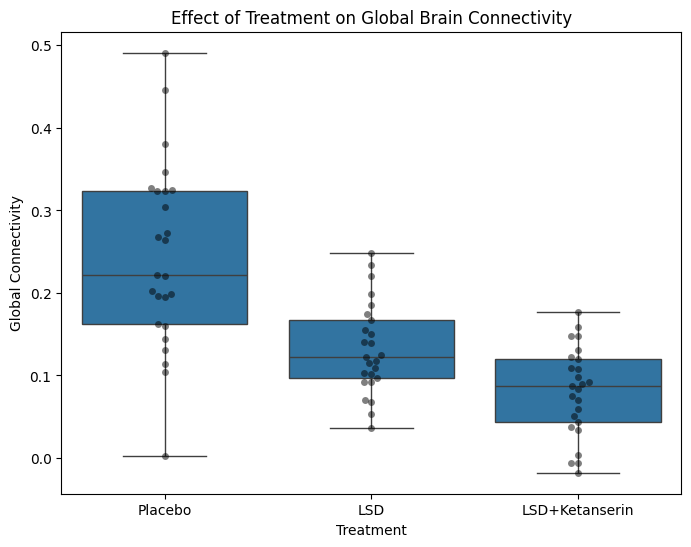

In [20]:
# 1. Compute FC using built-in compute_static_fc (Pearson correlation)
#    Input: (batch, n_rois, T) torch tensor → Output: (batch, n_rois, n_rois)
fc_placebo = compute_static_fc(torch.tensor(data['Placebo'], dtype=torch.float32))
fc_lsd = compute_static_fc(torch.tensor(data['LSD'], dtype=torch.float32))
fc_ket = compute_static_fc(torch.tensor(data['LSD+Ketanserin'], dtype=torch.float32))

# 2. Extract Mean Global Connectivity (upper triangle only)
triu_indices = np.triu_indices(n_rois, k=1)

df_fc = pd.DataFrame({
    'Placebo': [m[triu_indices].mean().item() for m in fc_placebo],
    'LSD': [m[triu_indices].mean().item() for m in fc_lsd],
    'LSD+Ketanserin': [m[triu_indices].mean().item() for m in fc_ket],
})

# Reshape for plotting
df_long = df_fc.melt(var_name='Treatment', value_name='Global Connectivity')

# 3. Visualize
plt.figure(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Global Connectivity', data=df_long)
sns.swarmplot(x='Treatment', y='Global Connectivity', data=df_long, color='black', alpha=0.5)
plt.title("Effect of Treatment on Global Brain Connectivity")
plt.show()

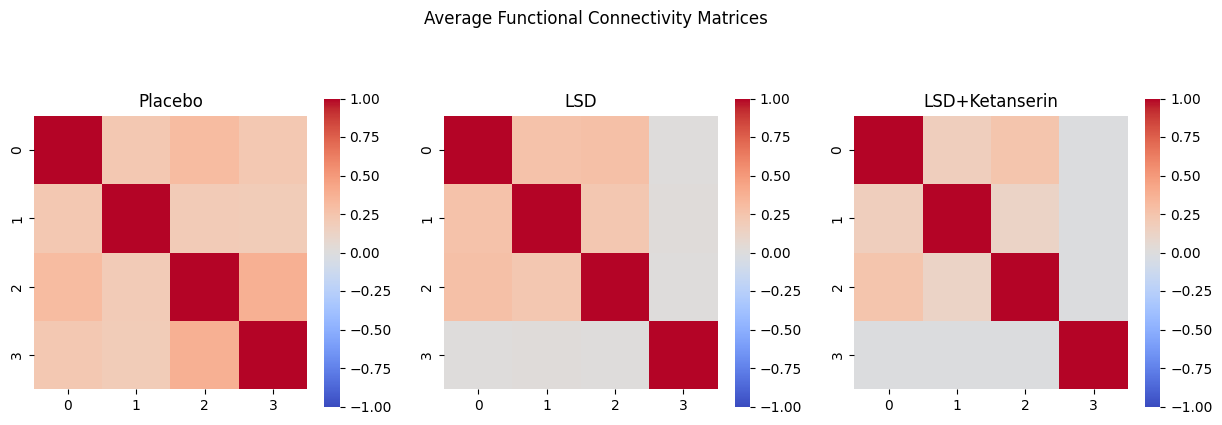

In [21]:
# Group-average FC matrices using Fisher-z averaging
fc_placebo_avg = fisher_batch_average(fc_placebo).numpy()
fc_lsd_avg = fisher_batch_average(fc_lsd).numpy()
fc_ket_avg = fisher_batch_average(fc_ket).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Placebo', 'LSD', 'LSD+Ketanserin']
for ax, fc_matrix, title in zip(axes, [fc_placebo_avg, fc_lsd_avg, fc_ket_avg], titles):
    sns.heatmap(fc_matrix, ax=ax, vmin=-1, vmax=1, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
    ax.set_title(title)
plt.suptitle("Average Functional Connectivity Matrices")
plt.show()

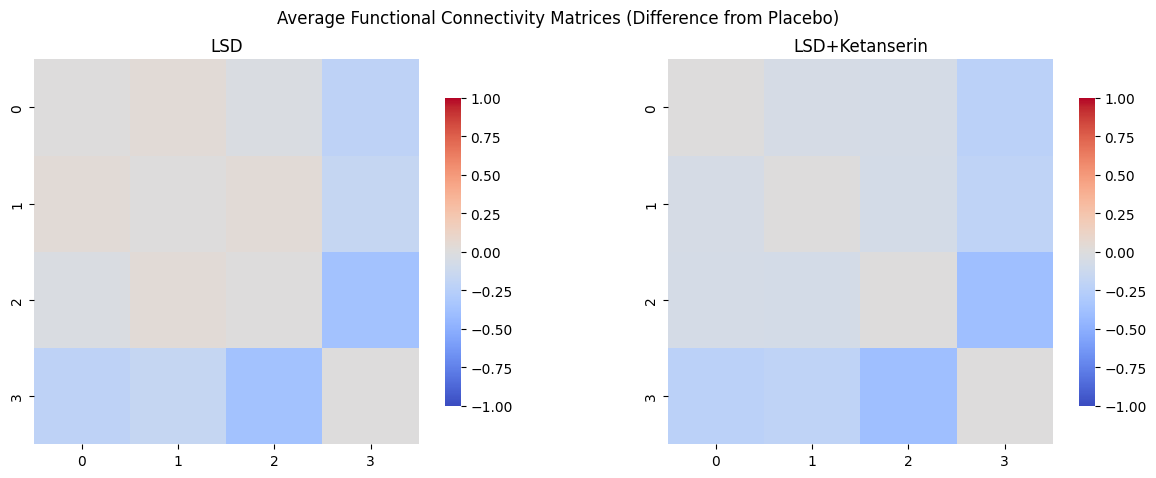

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
titles = ['LSD', 'LSD+Ketanserin']
for ax, fc_matrix, title in zip(axes, [fc_lsd_avg, fc_ket_avg], titles):
    sns.heatmap(fc_matrix - fc_placebo_avg, ax=ax, vmin=-1, vmax=1, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
    ax.set_title(title)
plt.suptitle("Average Functional Connectivity Matrices (Difference from Placebo)")
plt.show()

## Preprocessed FC (matching `postprocess.py` pipeline)

The plots above use raw time series. The `postprocess.py` pipeline applies three additional steps before computing FC:
1. **Z-score normalisation** per subject/ROI
2. **FFT brick-wall bandpass** (0.008–0.08 Hz) to isolate resting-state BOLD fluctuations
3. **Hilbert transform** → analytic signal (real part = filtered signal)

This removes high-frequency noise, cardiac/respiratory artefacts, and scanner drift, producing sharper drug-condition differences.

In [ ]:
from src.dataset import fft_bandpass_3d, hilbert_transform, compute_fc_from_timeseries

dt = 0.72          # TR in seconds
f_lo, f_hi = 0.008, 0.08   # resting-state BOLD band

def preprocess_ts(ts_np: np.ndarray) -> torch.Tensor:
    """Apply the postprocess.py pipeline: z-score → bandpass → Hilbert → real FC."""
    ts = torch.tensor(ts_np, dtype=torch.float32)  # (n_subs, n_rois, T)
    # 1. Z-score normalise
    mean = ts.mean(dim=2, keepdim=True)
    std  = ts.std(dim=2,  keepdim=True) + 1e-8
    ts = (ts - mean) / std
    # 2. Bandpass filter
    ts = fft_bandpass_3d(ts, dt, f_lo, f_hi)
    # 3. Hilbert transform → analytic signal
    ts = hilbert_transform(ts)
    return ts  # complex (n_subs, n_rois, T)

# Preprocess each condition
ts_placebo_p = preprocess_ts(data['Placebo'])
ts_lsd_p     = preprocess_ts(data['LSD'])
ts_ket_p     = preprocess_ts(data['LSD+Ketanserin'])

# Compute per-subject FC (Pearson on real part) and group-average with Fisher-z
fc_placebo_p = compute_fc_from_timeseries(ts_placebo_p)
fc_lsd_p     = compute_fc_from_timeseries(ts_lsd_p)
fc_ket_p     = compute_fc_from_timeseries(ts_ket_p)

fc_placebo_p_avg = fisher_batch_average(fc_placebo_p).numpy()
fc_lsd_p_avg     = fisher_batch_average(fc_lsd_p).numpy()
fc_ket_p_avg     = fisher_batch_average(fc_ket_p).numpy()

# --- Average FC matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, fc_mat, title in zip(axes,
                              [fc_placebo_p_avg, fc_lsd_p_avg, fc_ket_p_avg],
                              ['Placebo', 'LSD', 'LSD+Ketanserin']):
    sns.heatmap(fc_mat, ax=ax, vmin=-1, vmax=1, cmap='coolwarm', square=True,
                cbar_kws={"shrink": .8}, xticklabels=parts, yticklabels=parts)
    ax.set_title(title)
plt.suptitle("Average FC Matrices (preprocessed: z-score + bandpass + Hilbert)")
plt.tight_layout()
plt.show()

# --- ΔFC relative to Placebo (replicates fc_delta_empirical.pdf) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fc_mat, title in zip(axes,
                              [fc_lsd_p_avg, fc_ket_p_avg],
                              ['LSD', 'LSD+Ketanserin']):
    diff = fc_mat - fc_placebo_p_avg
    vmax_d = max(abs(diff.min()), abs(diff.max()), 1e-6)
    im = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"ΔFC: {title} − Placebo")
    ax.set_xticks(range(n_rois)); ax.set_xticklabels(parts, rotation=45, ha='right')
    ax.set_yticks(range(n_rois)); ax.set_yticklabels(parts)
    ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
plt.suptitle("Empirical — FC change under drug conditions (preprocessed)")
plt.tight_layout()
plt.show()